# Fase 2: Análisis estadístico

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df_final = pd.read_csv("./files/df_final.csv")
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   403760 non-null  int64  
 1   Loyalty Number               403760 non-null  int64  
 2   Year                         403760 non-null  int64  
 3   Month                        403760 non-null  int64  
 4   Flights Booked               403760 non-null  int64  
 5   Flights with Companions      403760 non-null  int64  
 6   Total Flights                403760 non-null  int64  
 7   Distance                     403760 non-null  int64  
 8   Points Accumulated           403760 non-null  float64
 9   Points Redeemed              403760 non-null  int64  
 10  Dollar Cost Points Redeemed  403760 non-null  int64  
 11  Country                      403760 non-null  str    
 12  Province                     403760 non-null  str    
 13  City      

### Variables numericas

In [11]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,403760.0,201879.500000,116555.616681,0.00,100939.75,201879.50,302819.25,403759.00
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00


In [6]:
# Creo una función para automatizar el análisis estadístico de una variable
# La función recibe dos parámetros: el DataFrame y la columna que quiero analizar
# Devuelve un nuevo DataFrame con estadísticas descriptivas principales

def resumen_analisis(df, columna):

    # Selecciono la columna elegida y elimino valores nulos (NaN)
    serie = df[columna].dropna()

    # Devuelvo un nuevo DataFrame con medidas estadísticas
    return pd.DataFrame({
        "media": [serie.mean()],          # promedio de los valores
        "mediana": [serie.median()],     # valor central de la distribución
        "std": [serie.std()],            # desviación estándar o dispersión
        "min": [serie.min()],            # valor mínimo
        "max": [serie.max()]             # valor máximo
    }).T                                # transpone filas y columnas

In [14]:
resumen_analisis(df_final,'Flights Booked')

,0
media,4.134050
mediana,1.000000
std,5.230064
min,0.000000
max,21.000000


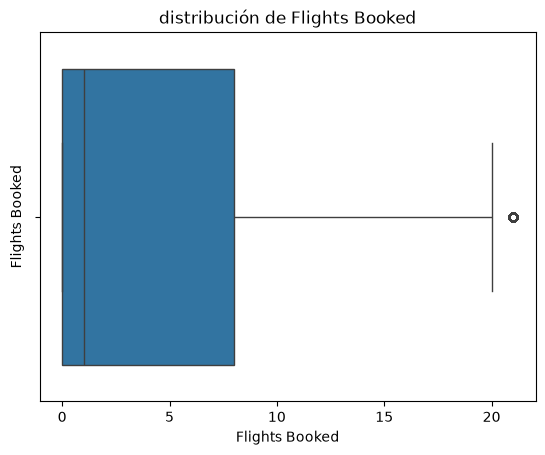

In [16]:
sns.boxplot(data=df_final, x='Flights Booked')
plt.title('distribución de Flights Booked')
plt.ylabel ('Flights Booked')
plt.show()

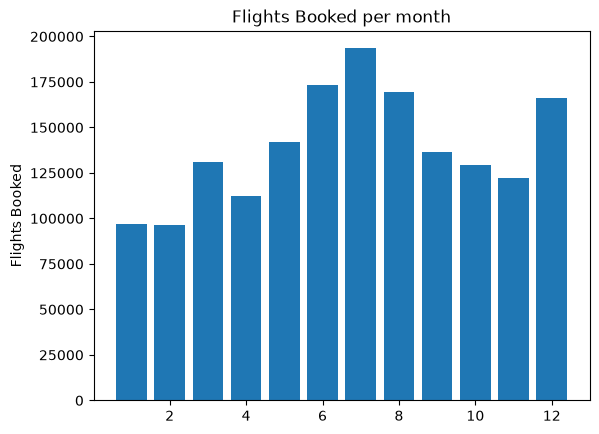

In [25]:
## grafico de vuelos por mes

fig, ax = plt.subplots()

flights_per_month = df_final.groupby('Month', as_index=False)['Flights Booked'].sum().to_numpy()

fruits = flights_per_month[:,0]
counts = flights_per_month[:,1]

bar_labels = df_final["Month"].unique()

ax.bar(fruits, counts, label=bar_labels)

ax.set_ylabel('Flights Booked')
ax.set_title('Flights Booked per month')


plt.show()

## Analisis de Flights Booked:
como podemos ver tanto en los numeros como en la grafica la mediana de Flights Booked es de 1, bastante bajo comparado con la media que es 4

In [15]:
resumen_analisis(df_final,'Flights with Companions')

,0
media,1.036569
mediana,0.000000
std,2.080472
min,0.000000
max,11.000000


## Analisis de Flights with Companions